Importem les llibreries de sempre i la nova

In [1]:
from matplotlib import pyplot as plt
import numpy as np

In [2]:
import MDAnalysis as mda

Mirem quina versió tenim instalada

In [3]:
print("Using MDAnalysis version", mda.__version__)

Using MDAnalysis version 2.10.0


#### Analisi estructura inicial

Ara crearem un "univers" amb les nostres dades sobre atoms

In [4]:
u=mda.Universe('adk.psf','adk.pdb')

/opt/anaconda3/envs/nanociencia/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:479: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn(


No sap la mida de la caixa i ens avisa per això el avis.

In [5]:
print(u)

<Universe with 3341 atoms>


Mirem la llista d'amonioacids

In [6]:
print(u.residues)

<ResidueGroup [<Residue MET, 1>, <Residue ARG, 2>, <Residue ILE, 3>, ..., <Residue ILE, 212>, <Residue LEU, 213>, <Residue GLY, 214>]>


Seleccionem els atoms, per poder fer alguns exemples

In [8]:
u.atoms

<AtomGroup with 3341 atoms>

Buscarem els ultims 5 atoms, en posar -5 els obtenim, si posesim 5 serian els cinc primers

In [9]:
last_five = u.atoms[-5:]
print(last_five)

<AtomGroup [<Atom 3337: HA1 of type 6 of resname GLY, resid 214 and segid 4AKE>, <Atom 3338: HA2 of type 6 of resname GLY, resid 214 and segid 4AKE>, <Atom 3339: C of type 32 of resname GLY, resid 214 and segid 4AKE>, <Atom 3340: OT1 of type 72 of resname GLY, resid 214 and segid 4AKE>, <Atom 3341: OT2 of type 72 of resname GLY, resid 214 and segid 4AKE>]>


Podem seleccionar els atoms que volguem. 

In [10]:
print(u.select_atoms('resname GLU')) #ens donara tots els atoms que equivalen a un glutamic

<AtomGroup [<Atom 318: N of type 54 of resname GLU, resid 22 and segid 4AKE>, <Atom 319: HN of type 1 of resname GLU, resid 22 and segid 4AKE>, <Atom 320: CA of type 22 of resname GLU, resid 22 and segid 4AKE>, ..., <Atom 3271: OE2 of type 72 of resname GLU, resid 210 and segid 4AKE>, <Atom 3272: C of type 20 of resname GLU, resid 210 and segid 4AKE>, <Atom 3273: O of type 70 of resname GLU, resid 210 and segid 4AKE>]>


In [11]:
print(u.atoms[:20].names) #obtindrem els noms d'aquests atoms

['N' 'HT1' 'HT2' 'HT3' 'CA' 'HA' 'CB' 'HB1' 'HB2' 'CG' 'HG1' 'HG2' 'SD'
 'CE' 'HE1' 'HE2' 'HE3' 'C' 'O' 'N']


In [13]:
print(u.atoms[:20].positions) #si volem les posicions

[[ 11.736   8.501 -10.445]
 [ 12.365   7.84  -10.835]
 [ 12.092   9.442 -10.725]
 [ 10.832   8.309 -10.964]
 [ 11.665   8.393  -8.983]
 [ 12.673   8.56   -8.681]
 [ 10.74    9.57   -8.591]
 [  9.639   9.27   -8.968]
 [ 11.095  10.519  -9.142]
 [ 10.557   9.934  -7.112]
 [ 11.449  10.323  -6.693]
 [ 10.277   8.979  -6.597]
 [  9.25   11.105  -6.91 ]
 [ 10.444  12.492  -7.162]
 [ 11.472  12.294  -7.661]
 [ 10.565  13.068  -6.252]
 [  9.883  13.172  -7.79 ]
 [ 11.167   7.129  -8.375]
 [ 10.151   6.649  -8.755]
 [ 11.841   6.642  -7.275]]


In [14]:
print(u.atoms[:20].charges) #si volem la carrega

[-0.30000001  0.33000001  0.33000001  0.33000001  0.20999999  0.1
 -0.18000001  0.09        0.09       -0.14        0.09        0.09
 -0.09       -0.22        0.09        0.09        0.09        0.50999999
 -0.50999999 -0.47      ]


In [17]:
print(u.atoms[:20].masses) #obtindrem les masses

[14.007  1.008  1.008  1.008 12.011  1.008 12.011  1.008  1.008 12.011
  1.008  1.008 32.06  12.011  1.008  1.008  1.008 12.011 15.999 14.007]


In [21]:
ca = u.select_atoms('resid 1-5 and name CA')
print(ca.positions)
 #estic seleccionant tots els carbonis alfas que pertanyen als residus 1-5 de la cadena

[[11.665  8.393 -8.983]
 [11.415  5.434 -6.513]
 [ 8.96   5.613 -3.613]
 [ 8.29   3.076 -0.797]
 [ 5.011  3.764  1.13 ]]


In [22]:
print(ca.center_of_mass()) #li diem que calculi el centre de masses

[ 9.06820002  5.2559999  -3.75519994]


In [24]:
nhh = u.atoms[:3]
print(nhh)#mirem els tres primers atoms 

<AtomGroup [<Atom 1: N of type 56 of resname MET, resid 1 and segid 4AKE>, <Atom 2: HT1 of type 2 of resname MET, resid 1 and segid 4AKE>, <Atom 3: HT2 of type 2 of resname MET, resid 1 and segid 4AKE>]>


In [26]:
angle_nhh = nhh.angle
print(f"N-H-H angle: {angle_nhh.value():.2f}") #obtenim els angles de la selecció anterior, al posar 2f diem que volem 2 decimals

N-H-H angle: 38.01


Aquest valor no está bé, ja que haig de tenir el N al vertex per obtenir el valor real

In [27]:
hnh = u.atoms[[1, 0, 2]]
print(hnh.names)

['HT1' 'N' 'HT2']


Ara tenim l'ordre correcte

In [28]:
angle_hnh = hnh.angle
print(f"H-N-H angle: {angle_hnh.value():.2f}")

H-N-H angle: 106.19


#### Analisi trajectoria

In [31]:
u=mda.Universe('adk.psf','unfolding.dcd')
#crearem un nou univers amb la evolució temporal

/opt/anaconda3/envs/nanociencia/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [32]:
print(len(u.trajectory))#mirem quants frames tenim i comprobem que tenim els mateixos que al VMD

98


In [33]:
print(u.trajectory)

<DCDReader unfolding.dcd with 98 frames of 3341 atoms>


In [35]:
print(u.trajectory.time) #estare a 0 perque inicialment es posa a 0

0.0


In [36]:
for ts in u.trajectory:
    time = u.trajectory.time
    rgyr = u.atoms.radius_of_gyration()
    print(f"Frame: {ts.frame:3d}, Time: {time:4.0f} ps, Rgyr: {rgyr:.4f} A")

Frame:   0, Time:    0 ps, Rgyr: 16.6690 A
Frame:   1, Time:    1 ps, Rgyr: 16.6732 A
Frame:   2, Time:    2 ps, Rgyr: 16.7315 A
Frame:   3, Time:    3 ps, Rgyr: 16.7223 A
Frame:   4, Time:    4 ps, Rgyr: 16.7440 A
Frame:   5, Time:    5 ps, Rgyr: 16.7185 A
Frame:   6, Time:    6 ps, Rgyr: 16.7741 A
Frame:   7, Time:    7 ps, Rgyr: 16.7764 A
Frame:   8, Time:    8 ps, Rgyr: 16.7894 A
Frame:   9, Time:    9 ps, Rgyr: 16.8289 A
Frame:  10, Time:   10 ps, Rgyr: 16.8521 A
Frame:  11, Time:   11 ps, Rgyr: 16.8549 A
Frame:  12, Time:   12 ps, Rgyr: 16.8723 A
Frame:  13, Time:   13 ps, Rgyr: 16.9108 A
Frame:  14, Time:   14 ps, Rgyr: 16.9494 A
Frame:  15, Time:   15 ps, Rgyr: 16.9810 A
Frame:  16, Time:   16 ps, Rgyr: 17.0033 A
Frame:  17, Time:   17 ps, Rgyr: 17.0196 A
Frame:  18, Time:   18 ps, Rgyr: 17.0784 A
Frame:  19, Time:   19 ps, Rgyr: 17.1265 A
Frame:  20, Time:   20 ps, Rgyr: 17.1491 A
Frame:  21, Time:   21 ps, Rgyr: 17.1759 A
Frame:  22, Time:   22 ps, Rgyr: 17.2168 A
Frame:  23,

In [37]:
rgyr = []
time = []
protein = u.select_atoms("protein")
for ts in u.trajectory:
    time.append(u.trajectory.time)
    rgyr.append(protein.radius_of_gyration())

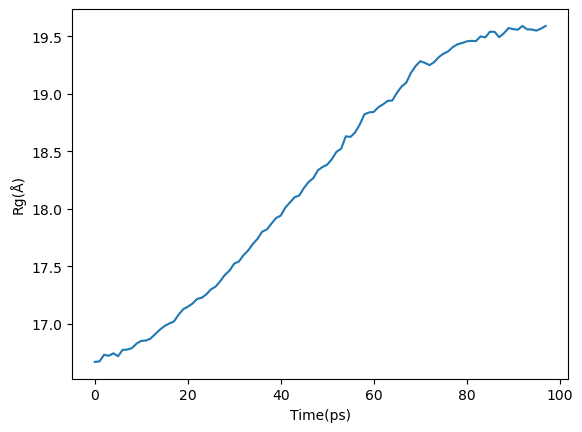

In [41]:
plt.plot(time,rgyr)
plt.xlabel('Time(ps)')
plt.ylabel('Rg(Å)')
plt.show()

**save data into file**

In [50]:
fitxer=open("Rg.dat","w")

In [51]:
for i in range(len(time)):
    fitxer.write(f'{round(time[i],1)} {round(rgyr[i],2)}\n')

In [52]:
fitxer.close()

la f vol dir que vull els valors